In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from torchvision import models

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [18]:
train_df = pd.read_csv("sign_mnist_train.csv")

test_df = pd.read_csv("sign_mnist_test.csv")

train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [19]:
X = train_df.drop("label", axis=1).values

y = train_df["label"].values

X_test = test_df.drop("label", axis=1).values

y_test = test_df["label"].values

# normalize

X = X / 255.0

X_test = X_test / 255.0

# reshape

X = X.reshape(-1,1,28,28)

X_test = X_test.reshape(-1,1,28,28)

# split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
X_train = torch.tensor(X_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)

y_val = torch.tensor(y_val, dtype=torch.long)

y_test = torch.tensor(y_test, dtype=torch.long)

In [21]:
train_dataset = TensorDataset(X_train, y_train)

val_dataset = TensorDataset(X_val, y_val)

test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64
)

In [22]:
class CNNModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Linear(64*7*7,128),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128,25)
        )

    def forward(self,x):

        x = self.conv(x)

        x = x.view(x.size(0),-1)

        x = self.fc(x)

        return x

In [23]:
class ResNetModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = models.resnet18(pretrained=True)

        self.model.conv1 = nn.Conv2d(
            1,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        self.model.fc = nn.Linear(512,25)

    def forward(self,x):

        return self.model(x)

In [24]:
class LSTMModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=28,
            hidden_size=128,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(128,25)

    def forward(self,x):

        x = x.squeeze(1)

        output, (hidden, cell) = self.lstm(x)

        out = self.fc(hidden[-1])

        return out

In [25]:
def train_model(model, epochs=10):

    model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_accs = []

    val_accs = []

    for epoch in range(epochs):

        # TRAIN

        model.train()

        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)

            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            _, preds = torch.max(outputs,1)

            total += labels.size(0)

            correct += (preds == labels).sum().item()

        train_acc = correct / total

        # VALIDATION

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)

                labels = labels.to(device)

                outputs = model(images)

                _, preds = torch.max(outputs,1)

                total += labels.size(0)

                correct += (preds == labels).sum().item()

        val_acc = correct / total

        train_accs.append(train_acc)

        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}")

        print("Train Accuracy:", train_acc)

        print("Validation Accuracy:", val_acc)

    return model, train_accs, val_accs

In [26]:
cnn_model = CNNModel()

cnn_model, cnn_train, cnn_val = train_model(
    cnn_model,
    epochs=10
)

Epoch 1
Train Accuracy: 0.38226188308140596
Validation Accuracy: 0.8033145146603533
Epoch 2
Train Accuracy: 0.7094791476962302
Validation Accuracy: 0.923511200145693
Epoch 3
Train Accuracy: 0.8078674194135859
Validation Accuracy: 0.966308504826079
Epoch 4
Train Accuracy: 0.8656893097796394
Validation Accuracy: 0.9894372609725005
Epoch 5
Train Accuracy: 0.8967856492442178
Validation Accuracy: 0.9956292114368968
Epoch 6
Train Accuracy: 0.9178655982516846
Validation Accuracy: 0.9974503733381898
Epoch 7
Train Accuracy: 0.932890183937352
Validation Accuracy: 0.9990894190493534
Epoch 8
Train Accuracy: 0.9394918958295393
Validation Accuracy: 0.9998178838098707
Epoch 9
Train Accuracy: 0.9459570205791294
Validation Accuracy: 0.9994536514296121
Epoch 10
Train Accuracy: 0.9529684938991076
Validation Accuracy: 1.0


In [27]:
resnet_model = ResNetModel()

resnet_model, res_train, res_val = train_model(
    resnet_model,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]


Epoch 1
Train Accuracy: 0.8332726279366236
Validation Accuracy: 0.9377162629757786
Epoch 2
Train Accuracy: 0.9653068657803678
Validation Accuracy: 0.9774175924239665
Epoch 3
Train Accuracy: 0.9831542524130396
Validation Accuracy: 0.9936259333454744
Epoch 4
Train Accuracy: 0.9864778728828993
Validation Accuracy: 0.9961755600072847
Epoch 5
Train Accuracy: 0.986705518120561
Validation Accuracy: 0.986705518120561


In [28]:
lstm_model = LSTMModel()

lstm_model, lstm_train, lstm_val = train_model(
    lstm_model,
    epochs=5
)

Epoch 1
Train Accuracy: 0.29029320706610817
Validation Accuracy: 0.565288654161355
Epoch 2
Train Accuracy: 0.7219541067200874
Validation Accuracy: 0.8186122746312147
Epoch 3
Train Accuracy: 0.887452194500091
Validation Accuracy: 0.9129484611181934
Epoch 4
Train Accuracy: 0.9592970315061009
Validation Accuracy: 0.9694044800582772
Epoch 5
Train Accuracy: 0.9714988162447642
Validation Accuracy: 0.9912584228737935


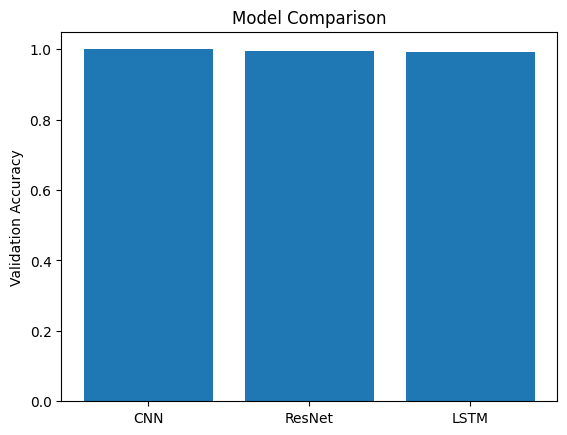

In [29]:
models_names = ["CNN","ResNet","LSTM"]

scores = [
    max(cnn_val),
    max(res_val),
    max(lstm_val)
]

plt.bar(models_names, scores)

plt.title("Model Comparison")

plt.ylabel("Validation Accuracy")

plt.show()

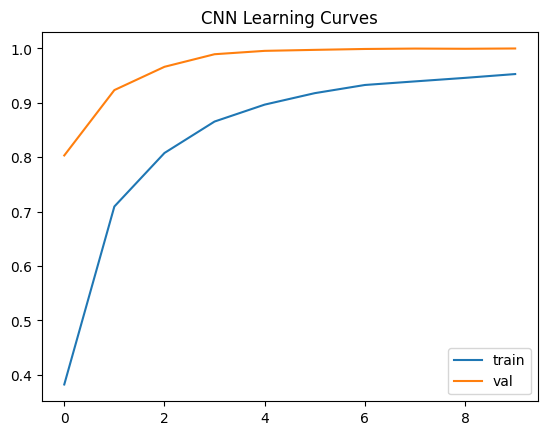

In [30]:
plt.plot(cnn_train,label='train')

plt.plot(cnn_val,label='val')

plt.legend()

plt.title("CNN Learning Curves")

plt.show()

In [31]:
cnn_model.eval()

predictions = []

true_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = cnn_model(images)

        _, preds = torch.max(outputs,1)

        predictions.extend(preds.cpu().numpy())

        true_labels.extend(labels.numpy())

acc = accuracy_score(true_labels, predictions)

print("Test Accuracy:", acc*100)

Test Accuracy: 90.63022866703848


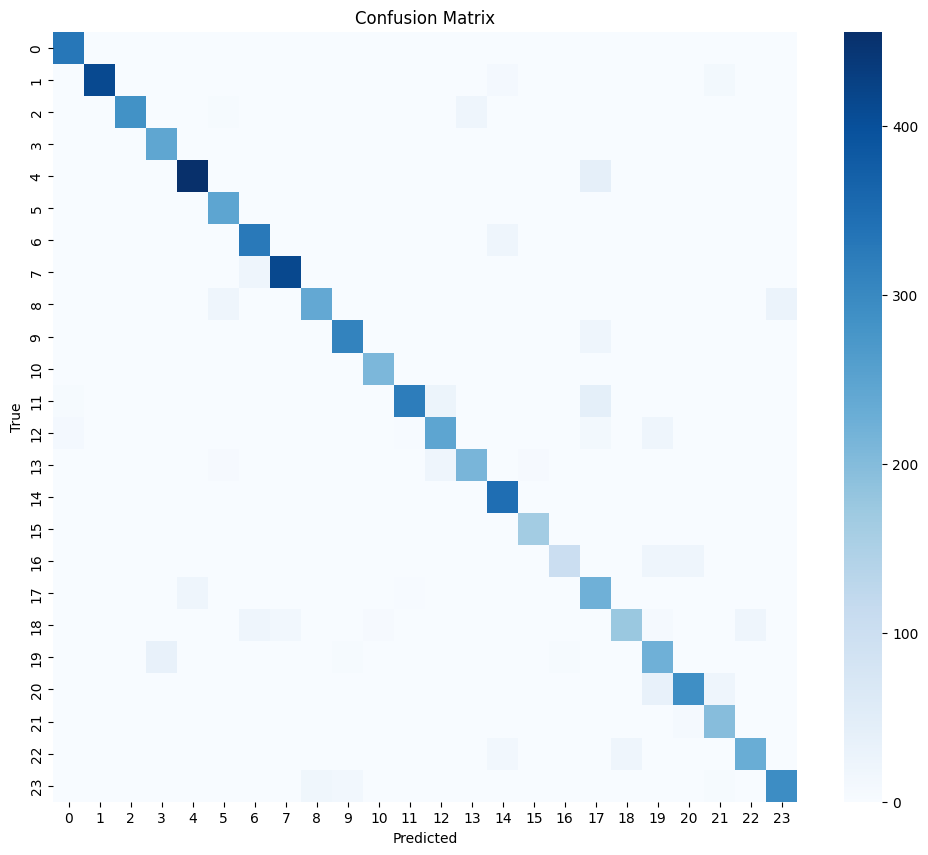

In [32]:
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(12,10))

sns.heatmap(cm, annot=False, cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()

In [33]:
print(classification_report(
    true_labels,
    predictions
))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       331
           1       1.00      0.95      0.98       432
           2       1.00      0.92      0.96       310
           3       0.88      1.00      0.94       245
           4       0.96      0.92      0.94       498
           5       0.89      1.00      0.94       247
           6       0.88      0.94      0.91       348
           7       0.96      0.95      0.96       436
           8       0.93      0.83      0.88       288
          10       0.94      0.94      0.94       331
          11       0.97      1.00      0.99       209
          12       0.98      0.81      0.89       394
          13       0.84      0.85      0.84       291
          14       0.91      0.86      0.89       246
          15       0.89      1.00      0.94       347
          16       0.96      1.00      0.98       164
          17       0.95      0.72      0.82       144
          18       0.65    

In [34]:
torch.save(
    cnn_model.state_dict(),
    "model_final.pth"
)

print("Model saved")

Model saved
